# EDA 21: Promotion Usage Rate Analysis

This notebook analyzes promotion usage at the order-item line level, how promotion intensity changes over time, and which categories or segments rely most heavily on promotions.

Promotion findings are exploratory. Forecast feature examples are historical and leakage-safe: they shift before rolling or lagging.

## 1. Setup and file discovery

Locate required and optional CSV files recursively from the current working directory. Missing files are reported clearly and dependent sections continue where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["order_items.csv", "promotions.csv", "products.csv"]
OPTIONAL_FILES = ["orders.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    all_csvs = list(root.rglob("*.csv"))
    found = {}
    for filename in filenames:
        target = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target]
        matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
        found[filename] = matches[0] if matches else None
    return found

file_paths = find_csv_files(ROOT, ALL_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "required": [name in REQUIRED_FILES for name in file_paths.keys()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

for name in REQUIRED_FILES:
    if file_paths.get(name) is None:
        display_warning(f"Required file {name} was not found. Dependent analysis will continue where possible.")
for name in OPTIONAL_FILES:
    if file_paths.get(name) is None:
        print(f"Note: Optional file {name} was not found. Date join from orders will be skipped.")

,file,path,required,status
0,order_items.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,True,found
1,promotions.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pr...,True,found
2,products.csv,D:\Code\Datathon 2026\datathon-2026-round-1\pr...,True,found
3,orders.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,False,found


## 2. Load order_items, promotions, products, and optional orders

Available CSV files are loaded safely with pandas. Column lists and samples are displayed to support schema validation.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}
order_items = data.get("order_items.csv")
promotions = data.get("promotions.csv")
products = data.get("products.csv")
orders = data.get("orders.csv")

load_summary = []
for name, df in data.items():
    load_summary.append(
        {
            "file": name,
            "loaded": df is not None,
            "rows": 0 if df is None else len(df),
            "columns": 0 if df is None else df.shape[1],
        }
    )
display(pd.DataFrame(load_summary))

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

,file,loaded,rows,columns
0,order_items.csv,True,714669,7
1,promotions.csv,True,50,10
2,products.csv,True,2412,8
3,orders.csv,True,646945,8



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN



promotions.csv columns:
['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']


,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0000,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0000,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0000,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0000,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0000,2013-07-30,2013-09-02,Streetwear,online,0,150000



products.csv columns:
['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.6500","9,704.8429"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.0760","5,393.8703"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.6332","11,371.9193"
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,"15,753.7173","8,573.1730"
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,"15,766.3345","14,063.5704"



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


## 3. Identify key, promo, date, product, category, segment, quantity, discount, and revenue columns

Column detection uses normalized names, numeric checks, date parsing, and join-key overlap. Promotion usage is inferred from promo/campaign/coupon identifiers, explicit flags, or positive discount amount.

In [3]:
def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    score = 0
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = [(score_column(col, include_terms, exclude_terms), col) for col in df.columns]
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5 or numeric.nunique(dropna=True) < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        n = normalize_name(col)
        parsed = pd.to_datetime(df[col], errors="coerce")
        valid_rate = parsed.notna().mean()
        unique_count = parsed.nunique(dropna=True)
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("order", 5), ("item", 4), ("start", 5), ("end", 5), ("created", 4)],
            [("id", 8), ("zip", 8), ("price", 8), ("amount", 8), ("quantity", 8), ("qty", 8), ("value", 6)],
        )
        has_date_name_hint = any(term in n for term in ["date", "time", "start", "end"])
        if not has_date_name_hint:
            continue
        if valid_rate >= 0.45 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(10000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(10000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

order_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]
product_terms = [("productid", 14), ("product", 8), ("sku", 6), ("itemid", 8), ("item", 4)]
promo_terms = [("promoid", 14), ("promotionid", 13), ("promo", 10), ("campaign", 9), ("coupon", 8), ("discountid", 8), ("offer", 5)]

item_order_col = choose_column_by_terms(order_items, order_terms, [("date", 6), ("amount", 4), ("status", 3)], min_score=4)
item_product_col, product_product_col = choose_common_key(order_items, products, product_terms) if products is not None else (None, None)
item_order_for_orders_col, order_order_col = choose_common_key(order_items, orders, order_terms) if orders is not None else (None, None)
item_date_col = choose_date_column(order_items, [("itemdate", 12), ("orderdate", 10), ("date", 8)]) if order_items is not None else None
order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8)]) if orders is not None else None

promo_id_cols = []
if order_items is not None:
    for col in order_items.columns:
        if score_column(col, promo_terms, [("date", 6), ("amount", 7), ("value", 7), ("price", 7), ("quantity", 7), ("qty", 7)]) >= 6:
            promo_id_cols.append(col)
promo_flag_col = choose_column_by_terms(order_items, [("promoflag", 12), ("promotionflag", 12), ("campaignflag", 10), ("couponflag", 8), ("flag", 4)], [("id", 8), ("amount", 6)], min_score=8)
promo_id_col_promotions = choose_column_by_terms(promotions, promo_terms, [("date", 6), ("amount", 6), ("value", 6)], min_score=6) if promotions is not None else None
promo_start_col = choose_date_column(promotions, [("startdate", 16), ("start", 10)]) if promotions is not None else None
promo_end_col = choose_date_column(promotions, [("enddate", 16), ("end", 10)]) if promotions is not None else None

category_col = choose_column_by_terms(products, [("category", 12), ("department", 8), ("class", 6)], [("id", 8), ("price", 6), ("cost", 6)], min_score=6) if products is not None else None
segment_col = choose_column_by_terms(products, [("segment", 12), ("tier", 7), ("group", 6), ("type", 5)], [("id", 8), ("date", 8), ("price", 6), ("cost", 6)], min_score=6) if products is not None else None
quantity_col = choose_numeric_column(order_items, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5)
price_col = choose_numeric_column(order_items, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5)
discount_col = choose_numeric_column(order_items, [("discountamount", 14), ("discount", 10), ("promoamount", 6)], [("id", 5), ("quantity", 8), ("qty", 8), ("price", 5)], min_score=5)
direct_revenue_col = choose_numeric_column(
    order_items,
    [("revenue", 12), ("sales", 10), ("total", 8), ("subtotal", 6), ("net", 6)],
    [("discount", 10), ("price", 8), ("cost", 8), ("quantity", 10), ("qty", 10), ("id", 10)],
    min_score=5,
)

detected = pd.DataFrame(
    [
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "order_items.order_id_for_orders", "column": item_order_for_orders_col},
        {"field": "orders.order_id", "column": order_order_col},
        {"field": "order_items.product_id", "column": item_product_col},
        {"field": "products.product_id", "column": product_product_col},
        {"field": "order_items.item_date", "column": item_date_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "order_items.promo_id_columns", "column": ", ".join(promo_id_cols) if promo_id_cols else None},
        {"field": "order_items.promo_flag", "column": promo_flag_col},
        {"field": "promotions.promo_id", "column": promo_id_col_promotions},
        {"field": "promotions.start_date", "column": promo_start_col},
        {"field": "promotions.end_date", "column": promo_end_col},
        {"field": "products.category", "column": category_col},
        {"field": "products.segment", "column": segment_col},
        {"field": "order_items.quantity", "column": quantity_col},
        {"field": "order_items.price", "column": price_col},
        {"field": "order_items.discount", "column": discount_col},
        {"field": "order_items.revenue", "column": direct_revenue_col},
    ]
)
display(detected)

required_ready = True
if order_items is None:
    display_warning("order_items.csv is required for line-level promotion usage analysis.")
    required_ready = False
if item_order_col is None:
    display_warning("Could not identify order ID in order_items.")
if products is None or item_product_col is None or product_product_col is None:
    display_warning("Product join fields are unavailable. Category and segment analysis may be skipped.")
if not promo_id_cols and promo_flag_col is None and discount_col is None:
    display_warning("No promo ID, promo flag, or discount field was identified. Promo usage analysis will be limited.")
if item_date_col is None and (orders is None or item_order_for_orders_col is None or order_order_col is None or order_date_col is None):
    display_warning("No item date was found and order-date join is unavailable. Time-based promotion analysis will be skipped.")

,field,column
0,order_items.order_id,order_id
1,order_items.order_id_for_orders,order_id
2,orders.order_id,order_id
3,order_items.product_id,product_id
4,products.product_id,product_id
5,order_items.item_date,None
6,orders.order_date,order_date
7,order_items.promo_id_columns,"promo_id, promo_id_2"
8,order_items.promo_flag,None
9,promotions.promo_id,promo_id


## 4. Build order-item promotion dataset

Create a line-level dataset with promo usage flags, product attributes, order dates, and item revenue where possible.

In [4]:
promo_items = pd.DataFrame()
promo_id_long = pd.DataFrame()
promo_match_summary = {}
promotion_date_quality = {}
revenue_available = False
date_available = False

def clean_id_series(series):
    return series.astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan, "NaN": np.nan})

if required_ready:
    promo_items = order_items.copy()
    promo_items["_line_id"] = np.arange(len(promo_items))
    if item_order_col is not None:
        promo_items["_order_id"] = promo_items[item_order_col].astype(str)
    if item_product_col is not None:
        promo_items["_product_id"] = promo_items[item_product_col].astype(str)

    if item_date_col is not None:
        promo_items["date"] = pd.to_datetime(promo_items[item_date_col], errors="coerce")
    elif orders is not None and item_order_for_orders_col is not None and order_order_col is not None and order_date_col is not None:
        orders_work = orders[[order_order_col, order_date_col]].copy()
        orders_work["_order_id"] = orders_work[order_order_col].astype(str)
        orders_work["date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce")
        promo_items = promo_items.merge(orders_work[["_order_id", "date"]].drop_duplicates("_order_id"), on="_order_id", how="left", indicator="_order_join")
    else:
        promo_items["date"] = pd.NaT
    date_available = promo_items["date"].notna().any()

    if products is not None and item_product_col is not None and product_product_col is not None:
        products_work = products.copy()
        products_work["_product_id"] = products_work[product_product_col].astype(str)
        product_cols = ["_product_id"]
        if category_col is not None:
            product_cols.append(category_col)
        if segment_col is not None:
            product_cols.append(segment_col)
        promo_items = promo_items.merge(products_work[product_cols].drop_duplicates("_product_id"), on="_product_id", how="left", indicator="_product_join")
    else:
        promo_items["_product_join"] = "not_available"
    if category_col is not None and category_col in promo_items.columns:
        promo_items["category"] = promo_items[category_col].fillna("Unknown").astype(str)
    else:
        promo_items["category"] = "Unknown"
    if segment_col is not None and segment_col in promo_items.columns:
        promo_items["segment"] = promo_items[segment_col].fillna("Unknown").astype(str)
    else:
        promo_items["segment"] = "Unknown"

    if quantity_col is not None:
        promo_items["quantity"] = pd.to_numeric(promo_items[quantity_col], errors="coerce")
    else:
        promo_items["quantity"] = np.nan
    if discount_col is not None:
        promo_items["discount_amount"] = pd.to_numeric(promo_items[discount_col], errors="coerce")
    else:
        promo_items["discount_amount"] = np.nan
    if direct_revenue_col is not None:
        promo_items["item_revenue"] = pd.to_numeric(promo_items[direct_revenue_col], errors="coerce")
    elif quantity_col is not None and price_col is not None:
        qty = pd.to_numeric(promo_items[quantity_col], errors="coerce")
        price = pd.to_numeric(promo_items[price_col], errors="coerce")
        discount = promo_items["discount_amount"].fillna(0) if discount_col is not None else 0
        promo_items["item_revenue"] = qty * price
    else:
        promo_items["item_revenue"] = np.nan
    revenue_available = promo_items["item_revenue"].notna().any()

    promo_id_masks = []
    primary_ids = pd.Series(np.nan, index=promo_items.index, dtype=object)
    for col in promo_id_cols:
        cleaned = clean_id_series(promo_items[col])
        promo_items[f"_{col}_clean"] = cleaned
        promo_id_masks.append(cleaned.notna())
        primary_ids = primary_ids.where(primary_ids.notna(), cleaned)
        temp = pd.DataFrame({"_line_id": promo_items["_line_id"], "promo_id": cleaned, "promo_source_column": col})
        promo_id_long = pd.concat([promo_id_long, temp.dropna(subset=["promo_id"])], ignore_index=True)
    promo_items["primary_promo_id"] = primary_ids
    promo_items["has_promo_id"] = primary_ids.notna()

    promo_flag_mask = pd.Series(False, index=promo_items.index)
    if promo_flag_col is not None and promo_flag_col in promo_items.columns:
        flag_values = promo_items[promo_flag_col]
        if pd.api.types.is_numeric_dtype(flag_values):
            promo_flag_mask = pd.to_numeric(flag_values, errors="coerce").fillna(0) > 0
        else:
            promo_flag_mask = flag_values.astype(str).str.lower().isin(["1", "true", "yes", "y", "promo", "promotion", "active"])
    discount_mask = promo_items["discount_amount"].fillna(0) > 0 if discount_col is not None else pd.Series(False, index=promo_items.index)
    promo_items["promo_used"] = promo_items["has_promo_id"] | promo_flag_mask | discount_mask

    if promotions is not None and promo_id_col_promotions is not None and not promo_id_long.empty:
        promotions_work = promotions.copy()
        promotions_work["_promo_id_clean"] = clean_id_series(promotions_work[promo_id_col_promotions])
        promo_ids_used = set(promo_id_long["promo_id"].dropna().astype(str))
        promo_ids_defined = set(promotions_work["_promo_id_clean"].dropna().astype(str))
        promo_match_summary = {
            "unique_promo_ids_used_in_items": len(promo_ids_used),
            "unique_promo_ids_defined": len(promo_ids_defined),
            "promo_ids_used_matched_to_promotions": len(promo_ids_used & promo_ids_defined),
            "promo_ids_used_not_found_in_promotions": len(promo_ids_used - promo_ids_defined),
            "promotions_with_no_matching_item_lines": len(promo_ids_defined - promo_ids_used),
        }
        promo_id_long = promo_id_long.merge(
            promotions_work[["_promo_id_clean"]].drop_duplicates().rename(columns={"_promo_id_clean": "promo_id"}),
            on="promo_id",
            how="left",
            indicator="_promo_join",
        )
    else:
        promo_match_summary = {
            "unique_promo_ids_used_in_items": int(promo_id_long["promo_id"].nunique()) if not promo_id_long.empty else 0,
            "unique_promo_ids_defined": np.nan,
            "promo_ids_used_matched_to_promotions": np.nan,
            "promo_ids_used_not_found_in_promotions": np.nan,
            "promotions_with_no_matching_item_lines": np.nan,
        }

    if promotions is not None and promo_start_col is not None and promo_end_col is not None:
        promo_dates = promotions.copy()
        promo_dates["_promo_start"] = pd.to_datetime(promo_dates[promo_start_col], errors="coerce")
        promo_dates["_promo_end"] = pd.to_datetime(promo_dates[promo_end_col], errors="coerce")
        promotion_date_quality = {
            "promotions_missing_start_date": int(promo_dates["_promo_start"].isna().sum()),
            "promotions_missing_end_date": int(promo_dates["_promo_end"].isna().sum()),
            "promotions_with_invalid_date_range": int((promo_dates["_promo_end"] < promo_dates["_promo_start"]).sum()),
        }

    keep_cols = ["_line_id", "_order_id" if "_order_id" in promo_items.columns else None, "_product_id" if "_product_id" in promo_items.columns else None, "date", "promo_used", "primary_promo_id", "category", "segment", "quantity", "discount_amount", "item_revenue"]
    keep_cols = [c for c in keep_cols if c is not None and c in promo_items.columns]
    display(promo_items[keep_cols].head(10))
else:
    display_warning("Skipping promotion dataset construction because order_items.csv is unavailable.")

,_line_id,_order_id,_product_id,date,promo_used,primary_promo_id,category,segment,quantity,discount_amount,item_revenue
0,0,1,2400,2012-07-04,False,NaN,GenZ,Trendy,7,0.0000,"7,967.5400"
1,1,2,609,2012-07-04,False,NaN,Streetwear,Everyday,7,0.0000,"71,163.7500"
2,2,3,396,2012-07-04,False,NaN,Streetwear,Balanced,3,0.0000,"33,660.9900"
3,3,4,635,2012-07-04,False,NaN,Streetwear,Everyday,5,0.0000,"53,196.2500"
4,4,6,1935,2012-07-06,False,NaN,Outdoor,Activewear,1,0.0000,"1,597.8400"
5,5,7,1934,2012-07-06,False,NaN,Outdoor,Activewear,6,0.0000,"9,800.9400"
6,6,8,1934,2012-07-06,False,NaN,Outdoor,Activewear,6,0.0000,"9,617.5200"
7,7,8,1935,2012-07-06,False,NaN,Outdoor,Activewear,4,0.0000,"6,570.0400"
8,8,9,1432,2012-07-06,False,NaN,Outdoor,Activewear,8,0.0000,"32,397.1200"
9,9,10,1431,2012-07-06,False,NaN,Outdoor,Activewear,5,0.0000,"19,886.8500"


## 5. Join and promotion data quality checks

Report product/order/promotion matching, missing promo identifiers, discount/promo inconsistencies, and invalid promotion dates.

In [5]:
quality_warnings = []
data_quality = {}

if not promo_items.empty:
    product_matched = int((promo_items["_product_join"] == "both").sum()) if "_product_join" in promo_items.columns else np.nan
    product_unmatched = int((promo_items["_product_join"] == "left_only").sum()) if "_product_join" in promo_items.columns else np.nan
    order_matched = int((promo_items["_order_join"] == "both").sum()) if "_order_join" in promo_items.columns else np.nan
    order_unmatched = int((promo_items["_order_join"] == "left_only").sum()) if "_order_join" in promo_items.columns else np.nan
    discount_positive_missing_promo_id = int(((promo_items["discount_amount"].fillna(0) > 0) & (~promo_items["has_promo_id"])).sum()) if discount_col is not None else np.nan
    promo_id_zero_discount = int((promo_items["has_promo_id"] & (promo_items["discount_amount"].fillna(0) <= 0)).sum()) if discount_col is not None else np.nan

    data_quality = {
        "order_items_rows": len(promo_items),
        "order_items_rows_matched_to_products": product_matched,
        "order_items_rows_unmatched_to_products": product_unmatched,
        "order_items_rows_matched_to_orders": order_matched,
        "order_items_rows_unmatched_to_orders": order_unmatched,
        "missing_promo_id_lines": int((~promo_items["has_promo_id"]).sum()),
        "promo_lines_detected": int(promo_items["promo_used"].sum()),
        "discount_gt_zero_missing_promo_id_lines": discount_positive_missing_promo_id,
        "promo_id_present_zero_or_blank_discount_lines": promo_id_zero_discount,
        "missing_dates_on_item_lines": int(promo_items["date"].isna().sum()),
        "missing_category_lines": int((promo_items["category"] == "Unknown").sum()),
        "missing_segment_lines": int((promo_items["segment"] == "Unknown").sum()),
    }
    data_quality.update(promo_match_summary)
    data_quality.update(promotion_date_quality)
    display(pd.DataFrame([data_quality]).T.rename(columns={0: "value"}))

    if data_quality.get("promo_ids_used_not_found_in_promotions", 0) and not promo_id_long.empty:
        print("Sample promo IDs in order_items not found in promotions:")
        display(promo_id_long.loc[promo_id_long.get("_promo_join", "") == "left_only", ["promo_id", "promo_source_column"]].drop_duplicates().head(20))

    if data_quality.get("discount_gt_zero_missing_promo_id_lines", 0):
        quality_warnings.append(f"{data_quality['discount_gt_zero_missing_promo_id_lines']:,} lines have discount > 0 but no promo ID")
    if data_quality.get("promo_id_present_zero_or_blank_discount_lines", 0):
        quality_warnings.append(f"{data_quality['promo_id_present_zero_or_blank_discount_lines']:,} lines have promo ID but zero/blank discount")
    if data_quality.get("promo_ids_used_not_found_in_promotions", 0):
        quality_warnings.append(f"{data_quality['promo_ids_used_not_found_in_promotions']:,} promo IDs used in items were not found in promotions")
    if data_quality.get("promotions_with_invalid_date_range", 0):
        quality_warnings.append(f"{data_quality['promotions_with_invalid_date_range']:,} promotion records have invalid date ranges")
    if data_quality.get("missing_dates_on_item_lines", 0):
        quality_warnings.append(f"{data_quality['missing_dates_on_item_lines']:,} item lines have missing dates")
else:
    display_warning("Promotion data quality checks skipped because line-level data is unavailable.")

,value
order_items_rows,714669
order_items_rows_matched_to_products,714669
order_items_rows_unmatched_to_products,0
order_items_rows_matched_to_orders,714669
order_items_rows_unmatched_to_orders,0
missing_promo_id_lines,438353
promo_lines_detected,276316
discount_gt_zero_missing_promo_id_lines,0
promo_id_present_zero_or_blank_discount_lines,0
missing_dates_on_item_lines,0


## 6. Overall promotion usage rate

Promotion usage is measured at the order-item line level. This is distinct from order-level promotion usage.

In [6]:
overall_summary = {}

if not promo_items.empty:
    total_lines = len(promo_items)
    promo_lines = int(promo_items["promo_used"].sum())
    nonpromo_lines = total_lines - promo_lines
    overall_summary = {
        "grain": "order-item line",
        "total_order_item_lines": total_lines,
        "promo_item_lines": promo_lines,
        "non_promo_item_lines": nonpromo_lines,
        "promo_line_usage_rate": promo_lines / total_lines if total_lines else np.nan,
        "unique_promotions_used": int(promo_id_long["promo_id"].nunique()) if not promo_id_long.empty else 0,
    }
    if quantity_col is not None:
        total_qty = promo_items["quantity"].sum()
        promo_qty = promo_items.loc[promo_items["promo_used"], "quantity"].sum()
        overall_summary["total_quantity"] = total_qty
        overall_summary["promo_quantity_share"] = promo_qty / total_qty if total_qty else np.nan
    if revenue_available:
        total_rev = promo_items["item_revenue"].sum()
        promo_rev = promo_items.loc[promo_items["promo_used"], "item_revenue"].sum()
        overall_summary["total_item_revenue"] = total_rev
        overall_summary["promo_revenue_share"] = promo_rev / total_rev if total_rev else np.nan
        overall_summary["average_promo_line_revenue"] = promo_items.loc[promo_items["promo_used"], "item_revenue"].mean()
        overall_summary["average_nonpromo_line_revenue"] = promo_items.loc[~promo_items["promo_used"], "item_revenue"].mean()
    display(pd.DataFrame([overall_summary]).T.rename(columns={0: "value"}))
else:
    display_warning("Overall promotion usage skipped because line-level data is unavailable.")

,value
grain,order-item line
total_order_item_lines,714669
promo_item_lines,276316
non_promo_item_lines,438353
promo_line_usage_rate,0.3866
unique_promotions_used,50
total_quantity,3213143
promo_quantity_share,0.3865
total_item_revenue,"16,430,476,585.5300"
promo_revenue_share,0.3308


## 7. Promotion usage over time

Promotion usage is aggregated by day, month, and year to identify changes in promotion intensity.

,month,total_item_lines,promo_item_lines,unique_promo_count,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share
102,2021-01-01,1471,74,2,6577,334,"46,473,094.4200","1,462,566.7000",0.0503,0.0508,0.0315
103,2021-02-01,2101,558,1,9516,2539,"66,077,638.5700","6,875,831.6300",0.2656,0.2668,0.1041
104,2021-03-01,4305,2361,2,19186,10554,"113,274,006.6300","58,226,863.4200",0.5484,0.5501,0.5140
105,2021-04-01,4615,2299,1,20753,10309,"134,836,887.5300","62,127,629.4700",0.4982,0.4967,0.4608
106,2021-05-01,4484,0,0,20223,0,"143,070,694.8700",0.0000,0.0000,0.0000,0.0000
107,2021-06-01,4140,986,1,18404,4283,"128,449,576.2600","25,978,477.2200",0.2382,0.2327,0.2022
108,2021-07-01,3429,2132,2,15239,9342,"101,001,502.3000","56,889,498.5600",0.6218,0.6130,0.5633
109,2021-08-01,3373,2168,2,15181,9709,"68,280,026.8200","48,459,239.9000",0.6428,0.6395,0.7097
110,2021-09-01,2573,2465,2,11488,10980,"74,841,850.2600","73,019,451.6200",0.9580,0.9558,0.9757
111,2021-10-01,1964,156,1,8881,683,"65,692,136.1600","4,305,145.5000",0.0794,0.0769,0.0655


,year,total_item_lines,promo_item_lines,unique_promo_count,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share
0,2012,37007,0,0,166286,0,"741,497,748.0200",0.0000,0.0000,0.0000,0.0000
1,2013,87341,40529,6,392522,182498,"1,657,169,417.2700","661,883,250.2000",0.4640,0.4649,0.3994
2,2014,91086,33965,5,410283,152858,"1,871,845,882.8000","576,705,064.4100",0.3729,0.3726,0.3081
3,2015,92537,42988,7,415509,193073,"1,889,933,826.9200","744,577,803.8800",0.4645,0.4647,0.3940
4,2016,90895,31882,5,409893,143440,"2,104,640,677.5400","621,586,211.4000",0.3508,0.3499,0.2953
5,2017,83691,37193,7,375640,167192,"1,911,164,325.2800","733,069,687.5700",0.4444,0.4451,0.3836
6,2018,75132,25250,5,337646,113659,"1,850,122,456.0800","544,401,753.3200",0.3361,0.3366,0.2943
7,2019,44925,20244,7,202653,90979,"1,136,801,441.5100","436,354,158.7600",0.4506,0.4489,0.3838
8,2020,37238,13654,5,166880,61415,"1,054,512,158.7900","337,376,967.3000",0.3667,0.3680,0.3199
9,2021,36749,16447,7,164743,73381,"1,043,039,819.6300","405,360,380.4300",0.4475,0.4454,0.3886


Highest promotion-intensity months:


,month,total_item_lines,promo_item_lines,unique_promo_count,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share
113,2021-12-01,2519,2515,1,11447,11424,"50,403,908.3500","50,270,615.6800",0.9984,0.9980,0.9974
101,2020-12-01,2509,2505,1,11160,11145,"43,671,563.7700","43,588,944.8900",0.9984,0.9987,0.9981
17,2013-12-01,8279,8254,1,37248,37138,"91,285,868.4400","90,647,082.8800",0.9970,0.9970,0.9930
29,2014-12-01,8600,8571,1,38514,38372,"103,756,697.9400","102,959,424.7100",0.9966,0.9963,0.9923
65,2017-12-01,5876,5855,1,26100,26018,"83,739,779.5700","83,315,402.3900",0.9964,0.9969,0.9949
53,2016-12-01,7549,7519,1,33826,33662,"105,617,010.0600","104,872,403.1700",0.9960,0.9952,0.9929
89,2019-12-01,3257,3244,1,14572,14507,"48,431,556.1900","48,017,127.8700",0.9960,0.9955,0.9914
41,2015-12-01,8423,8375,1,37882,37662,"105,849,396.4400","104,812,204.7100",0.9943,0.9942,0.9902
77,2018-12-01,3805,3783,1,17251,17148,"61,269,893.7700","60,584,644.8100",0.9942,0.9940,0.9888
125,2022-12-01,2714,2698,1,12147,12064,"52,454,936.2000","51,828,881.7700",0.9941,0.9932,0.9881


Lowest promotion-intensity months:


,month,total_item_lines,promo_item_lines,unique_promo_count,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share
0,2012-07-01,5887,0,0,26384,0,"130,406,773.5100",0.0000,0.0000,0.0000,0.0000
1,2012-08-01,7166,0,0,32243,0,"159,089,240.3100",0.0000,0.0000,0.0000,0.0000
2,2012-09-01,5857,0,0,26319,0,"129,307,133.8200",0.0000,0.0000,0.0000,0.0000
3,2012-10-01,4877,0,0,22015,0,"110,185,694.4500",0.0000,0.0000,0.0000,0.0000
4,2012-11-01,4877,0,0,21747,0,"98,186,295.2400",0.0000,0.0000,0.0000,0.0000
5,2012-12-01,8343,0,0,37578,0,"114,322,610.6900",0.0000,0.0000,0.0000,0.0000
10,2013-05-01,9288,0,0,41806,0,"200,500,109.4800",0.0000,0.0000,0.0000,0.0000
19,2014-02-01,4828,0,0,21836,0,"108,440,957.1100",0.0000,0.0000,0.0000,0.0000
22,2014-05-01,10762,0,0,48882,0,"244,309,542.3200",0.0000,0.0000,0.0000,0.0000
46,2016-05-01,10787,0,0,48272,0,"268,131,883.6200",0.0000,0.0000,0.0000,0.0000


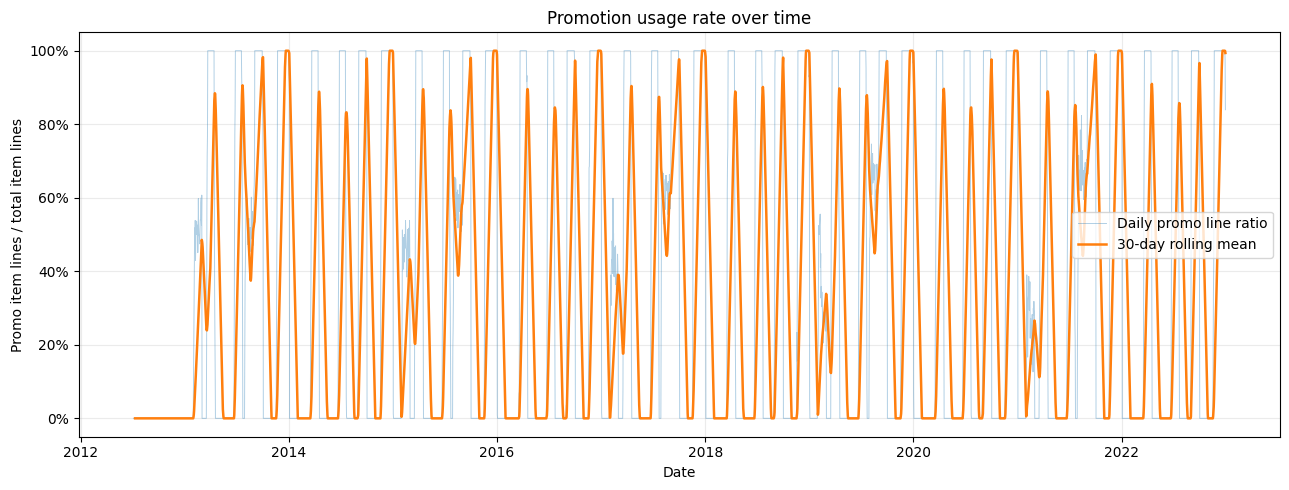

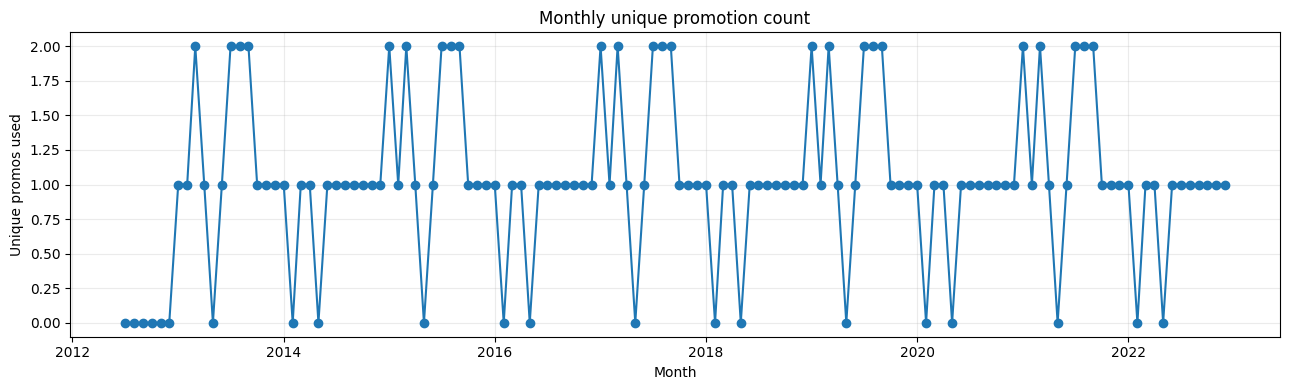

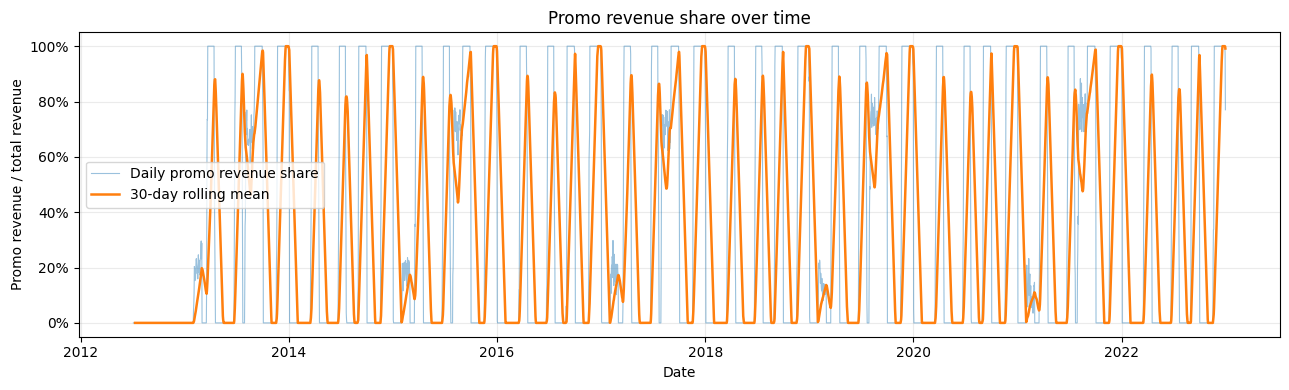

In [7]:
daily_promo = pd.DataFrame()
monthly_promo = pd.DataFrame()
yearly_promo = pd.DataFrame()
high_low_promo_periods = {}

if not promo_items.empty and date_available:
    dated = promo_items.dropna(subset=["date"]).copy()
    dated["date"] = dated["date"].dt.floor("D")
    dated["month"] = dated["date"].dt.to_period("M").dt.to_timestamp()
    dated["year"] = dated["date"].dt.year
    dated["month_of_year"] = dated["date"].dt.month
    dated["quarter"] = dated["date"].dt.quarter

    def aggregate_promo(df, group_cols):
        out = df.groupby(group_cols).agg(
            total_item_lines=("_line_id", "size"),
            promo_item_lines=("promo_used", "sum"),
            unique_promo_count=("primary_promo_id", "nunique"),
            total_quantity=("quantity", "sum"),
            promo_quantity=("quantity", lambda s: s[df.loc[s.index, "promo_used"]].sum()),
            total_revenue=("item_revenue", "sum"),
            promo_revenue=("item_revenue", lambda s: s[df.loc[s.index, "promo_used"]].sum()),
        ).reset_index()
        out["promo_line_ratio"] = out["promo_item_lines"] / out["total_item_lines"].replace(0, np.nan)
        out["promo_quantity_share"] = out["promo_quantity"] / out["total_quantity"].replace(0, np.nan)
        out["promo_revenue_share"] = out["promo_revenue"] / out["total_revenue"].replace(0, np.nan)
        return out

    daily_promo = aggregate_promo(dated, ["date"]).sort_values("date")
    full_index = pd.date_range(daily_promo["date"].min(), daily_promo["date"].max(), freq="D")
    daily_promo = daily_promo.set_index("date").reindex(full_index).rename_axis("date").reset_index()
    for col in ["total_item_lines", "promo_item_lines", "unique_promo_count", "total_quantity", "promo_quantity", "total_revenue", "promo_revenue"]:
        daily_promo[col] = daily_promo[col].fillna(0)
    daily_promo["promo_line_ratio"] = daily_promo["promo_item_lines"] / daily_promo["total_item_lines"].replace(0, np.nan)
    daily_promo["promo_quantity_share"] = daily_promo["promo_quantity"] / daily_promo["total_quantity"].replace(0, np.nan)
    daily_promo["promo_revenue_share"] = daily_promo["promo_revenue"] / daily_promo["total_revenue"].replace(0, np.nan)
    daily_promo["month_of_year"] = daily_promo["date"].dt.month
    daily_promo["quarter"] = daily_promo["date"].dt.quarter
    daily_promo["year"] = daily_promo["date"].dt.year

    monthly_promo = aggregate_promo(dated, ["month"]).sort_values("month")
    yearly_promo = aggregate_promo(dated, ["year"]).sort_values("year")
    display(monthly_promo.tail(24))
    display(yearly_promo)

    high_month = monthly_promo.sort_values("promo_line_ratio", ascending=False).head(10)
    low_month = monthly_promo.sort_values("promo_line_ratio", ascending=True).head(10)
    high_year = yearly_promo.sort_values("promo_line_ratio", ascending=False).head(5)
    low_year = yearly_promo.sort_values("promo_line_ratio", ascending=True).head(5)
    high_low_promo_periods = {"high_month": high_month, "low_month": low_month, "high_year": high_year, "low_year": low_year}
    print("Highest promotion-intensity months:")
    display(high_month)
    print("Lowest promotion-intensity months:")
    display(low_month)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(daily_promo["date"], daily_promo["promo_line_ratio"], alpha=0.35, linewidth=0.7, label="Daily promo line ratio")
    ax.plot(daily_promo["date"], daily_promo["promo_line_ratio"].rolling(30, min_periods=7).mean(), linewidth=1.8, label="30-day rolling mean")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Promotion usage rate over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Promo item lines / total item lines")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(monthly_promo["month"], monthly_promo["unique_promo_count"], marker="o")
    ax.set_title("Monthly unique promotion count")
    ax.set_xlabel("Month")
    ax.set_ylabel("Unique promos used")
    plt.tight_layout()
    plt.show()

    if revenue_available:
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(daily_promo["date"], daily_promo["promo_revenue_share"], alpha=0.45, linewidth=0.8, label="Daily promo revenue share")
        ax.plot(daily_promo["date"], daily_promo["promo_revenue_share"].rolling(30, min_periods=7).mean(), linewidth=1.8, label="30-day rolling mean")
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title("Promo revenue share over time")
        ax.set_xlabel("Date")
        ax.set_ylabel("Promo revenue / total revenue")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    display_warning("Promotion usage over time skipped because item dates are unavailable.")

## 8. Promotion usage by category

Calculate promotion usage by product category and identify categories that rely heavily on promotions. Small groups are flagged.

,category,total_item_lines,promo_item_lines,unique_promotions_used,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share,revenue_share,small_sample_flag
2,Outdoor,259986,108341,45,1170000,488306,"2,494,882,754.2000","905,670,857.1100",0.4167,0.4174,0.3630,0.1518,False
3,Streetwear,393533,147668,45,1768826,663232,"13,131,346,352.6200","4,290,286,430.2500",0.3752,0.3750,0.3267,0.7992,False
0,Casual,23991,8075,40,107469,35990,"460,648,383.3500","138,691,520.1000",0.3366,0.3349,0.3011,0.0280,False
1,GenZ,37159,12232,40,166848,54511,"343,599,095.3600","100,788,725.1700",0.3292,0.3267,0.2933,0.0209,False


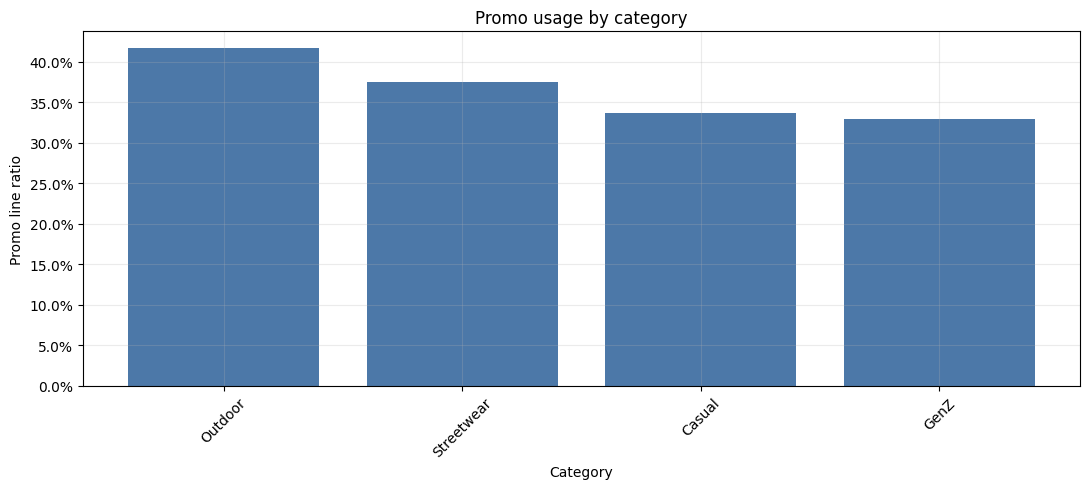

In [8]:
category_summary = pd.DataFrame()

def group_promo_summary(df, group_col):
    out = df.groupby(group_col).agg(
        total_item_lines=("_line_id", "size"),
        promo_item_lines=("promo_used", "sum"),
        unique_promotions_used=("primary_promo_id", "nunique"),
        total_quantity=("quantity", "sum"),
        promo_quantity=("quantity", lambda s: s[df.loc[s.index, "promo_used"]].sum()),
        total_revenue=("item_revenue", "sum"),
        promo_revenue=("item_revenue", lambda s: s[df.loc[s.index, "promo_used"]].sum()),
    ).reset_index()
    out["promo_line_ratio"] = out["promo_item_lines"] / out["total_item_lines"].replace(0, np.nan)
    out["promo_quantity_share"] = out["promo_quantity"] / out["total_quantity"].replace(0, np.nan)
    out["promo_revenue_share"] = out["promo_revenue"] / out["total_revenue"].replace(0, np.nan)
    out["revenue_share"] = out["total_revenue"] / out["total_revenue"].sum() if out["total_revenue"].sum() else np.nan
    out["small_sample_flag"] = out["total_item_lines"] < max(30, out["total_item_lines"].median() * 0.1)
    return out.sort_values("promo_line_ratio", ascending=False)

if not promo_items.empty and "category" in promo_items.columns and not (promo_items["category"] == "Unknown").all():
    category_summary = group_promo_summary(promo_items, "category")
    display(category_summary)

    fig, ax = plt.subplots(figsize=(11, 5))
    plot_df = category_summary.sort_values("promo_line_ratio", ascending=False).head(20)
    ax.bar(plot_df["category"].astype(str), plot_df["promo_line_ratio"], color="#4C78A8")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Promo usage by category")
    ax.set_xlabel("Category")
    ax.set_ylabel("Promo line ratio")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Category data is unavailable. Promotion usage by category cannot be performed.")

## 9. Promotion usage by segment

Calculate promotion usage by product segment when segment data is available.

,segment,total_item_lines,promo_item_lines,unique_promotions_used,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share,revenue_share,small_sample_flag
0,Activewear,230375,96696,45,1036857,435699,"2,047,815,224.1800","746,445,022.8500",0.4197,0.4202,0.3645,0.1246,False
6,Standard,10937,4290,45,49475,19480,"236,677,145.7000","82,022,330.8900",0.3922,0.3937,0.3466,0.0144,False
5,Premium,31032,12124,45,139465,54789,"480,131,388.3900","169,428,441.5800",0.3907,0.3929,0.3529,0.0292,False
2,Balanced,103333,39404,45,464217,176077,"5,127,408,523.4800","1,698,333,385.4800",0.3813,0.3793,0.3312,0.3121,False
4,Performance,96730,36226,45,435685,163516,"2,390,412,021.1700","785,056,408.4400",0.3745,0.3753,0.3284,0.1455,False
3,Everyday,182533,67748,45,819449,304159,"5,376,848,662.2700","1,724,874,305.4400",0.3712,0.3712,0.3208,0.3272,False
1,All-weather,22570,7596,40,101147,33808,"427,584,524.9800","128,488,912.7800",0.3366,0.3342,0.3005,0.0260,False
7,Trendy,37159,12232,40,166848,54511,"343,599,095.3600","100,788,725.1700",0.3292,0.3267,0.2933,0.0209,False


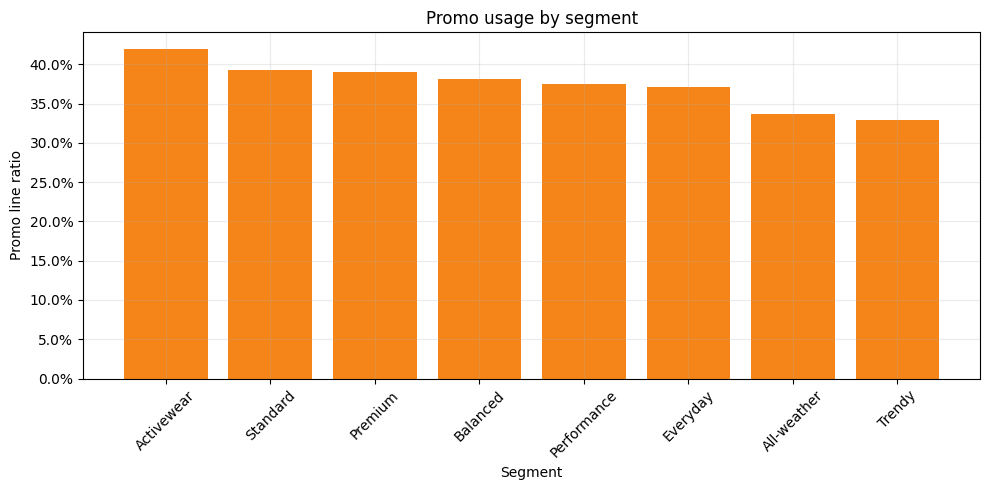

In [9]:
segment_summary = pd.DataFrame()

if not promo_items.empty and "segment" in promo_items.columns and not (promo_items["segment"] == "Unknown").all():
    segment_summary = group_promo_summary(promo_items, "segment")
    display(segment_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = segment_summary.sort_values("promo_line_ratio", ascending=False).head(20)
    ax.bar(plot_df["segment"].astype(str), plot_df["promo_line_ratio"], color="#F58518")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Promo usage by segment")
    ax.set_xlabel("Segment")
    ax.set_ylabel("Promo line ratio")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Segment data is unavailable. Promotion usage by segment is skipped.")

## 10. Promotion usage and revenue context

Compare promo and non-promo line revenue, and inspect whether promo-heavy categories are also major revenue contributors.

,promo_used,item_lines,revenue,avg_item_revenue,median_item_revenue,quantity,line_share,revenue_share
0,False,438353,"10,995,039,052.9000","25,082.6139","17,304.5100",1971104,0.6134,0.6692
1,True,276316,"5,435,437,532.6300","19,671.0923","12,818.7400",1242039,0.3866,0.3308


,category,total_item_lines,promo_item_lines,unique_promotions_used,total_quantity,promo_quantity,total_revenue,promo_revenue,promo_line_ratio,promo_quantity_share,promo_revenue_share,revenue_share,small_sample_flag,promo_revenue_context
3,Streetwear,393533,147668,45,1768826,663232,"13,131,346,352.6200","4,290,286,430.2500",0.3752,0.3750,0.3267,0.7992,False,high revenue and high promo usage
2,Outdoor,259986,108341,45,1170000,488306,"2,494,882,754.2000","905,670,857.1100",0.4167,0.4174,0.3630,0.1518,False,high revenue and high promo usage
0,Casual,23991,8075,40,107469,35990,"460,648,383.3500","138,691,520.1000",0.3366,0.3349,0.3011,0.0280,False,low revenue and low promo usage
1,GenZ,37159,12232,40,166848,54511,"343,599,095.3600","100,788,725.1700",0.3292,0.3267,0.2933,0.0209,False,low revenue and low promo usage


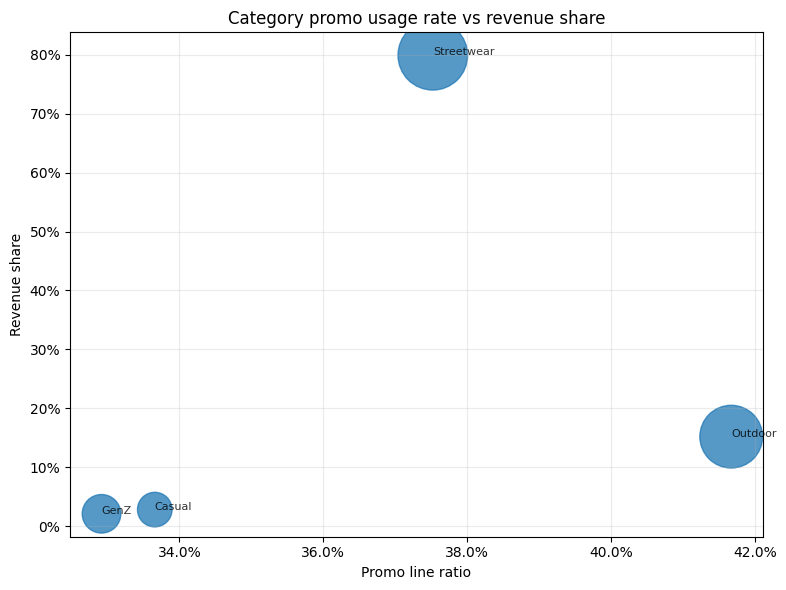

In [10]:
promo_revenue_context = pd.DataFrame()
category_quadrants = pd.DataFrame()

if not promo_items.empty and revenue_available:
    promo_revenue_context = promo_items.groupby("promo_used").agg(
        item_lines=("_line_id", "size"),
        revenue=("item_revenue", "sum"),
        avg_item_revenue=("item_revenue", "mean"),
        median_item_revenue=("item_revenue", "median"),
        quantity=("quantity", "sum"),
    ).reset_index()
    promo_revenue_context["line_share"] = promo_revenue_context["item_lines"] / promo_revenue_context["item_lines"].sum()
    promo_revenue_context["revenue_share"] = promo_revenue_context["revenue"] / promo_revenue_context["revenue"].sum()
    display(promo_revenue_context)

    if not category_summary.empty:
        revenue_threshold = category_summary["revenue_share"].median()
        promo_threshold = category_summary["promo_line_ratio"].median()
        category_quadrants = category_summary.copy()
        category_quadrants["promo_revenue_context"] = np.select(
            [
                (category_quadrants["revenue_share"] >= revenue_threshold) & (category_quadrants["promo_line_ratio"] >= promo_threshold),
                (category_quadrants["revenue_share"] >= revenue_threshold) & (category_quadrants["promo_line_ratio"] < promo_threshold),
                (category_quadrants["revenue_share"] < revenue_threshold) & (category_quadrants["promo_line_ratio"] >= promo_threshold),
            ],
            ["high revenue and high promo usage", "high revenue and low promo usage", "low revenue and high promo usage"],
            default="low revenue and low promo usage",
        )
        display(category_quadrants.sort_values(["revenue_share", "promo_line_ratio"], ascending=False))

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(category_summary["promo_line_ratio"], category_summary["revenue_share"], s=np.sqrt(category_summary["total_item_lines"]) * 4, alpha=0.75)
        for row in category_summary.to_dict("records"):
            ax.annotate(str(row["category"]), (row["promo_line_ratio"], row["revenue_share"]), fontsize=8, alpha=0.8)
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title("Category promo usage rate vs revenue share")
        ax.set_xlabel("Promo line ratio")
        ax.set_ylabel("Revenue share")
        plt.tight_layout()
        plt.show()
else:
    print("Revenue is unavailable. Promotion usage and revenue context is skipped.")

## 11. Promotion intensity seasonality

Historical promotion usage is summarized by month of year, quarter, and year. These summaries can support historical promotion-intensity features when future promotion plans are unknown.

,month_of_year,average_daily_promo_line_ratio,median_daily_promo_line_ratio,total_item_lines,promo_item_lines,average_unique_promo_count,aggregate_promo_line_ratio
0,1,0.0362,0.0000,33327,2684,0.0839,0.0805
1,2,0.1946,0.0000,38910,8495,0.4965,0.2183
2,3,0.3907,0.0000,63049,35218,0.4677,0.5586
3,4,0.5032,0.5454,81118,36685,0.5667,0.4522
4,5,0.0000,0.0000,80141,0,0.0000,0.0000
5,6,0.1995,0.0000,78294,20165,0.2667,0.2576
6,7,0.5979,1.0000,67803,38340,0.6805,0.5655
7,8,0.2745,0.0000,71736,19186,0.5103,0.2675
8,9,0.8777,1.0000,53539,44783,0.9394,0.8365
9,10,0.0276,0.0000,44073,1547,0.0381,0.0351


,quarter,average_daily_promo_line_ratio,total_item_lines,promo_item_lines,aggregate_promo_line_ratio
0,1,0.2076,135286,46397,0.3430
1,2,0.2317,239553,56850,0.2373
2,3,0.5801,193078,102309,0.5299
3,4,0.4235,146752,70760,0.4822


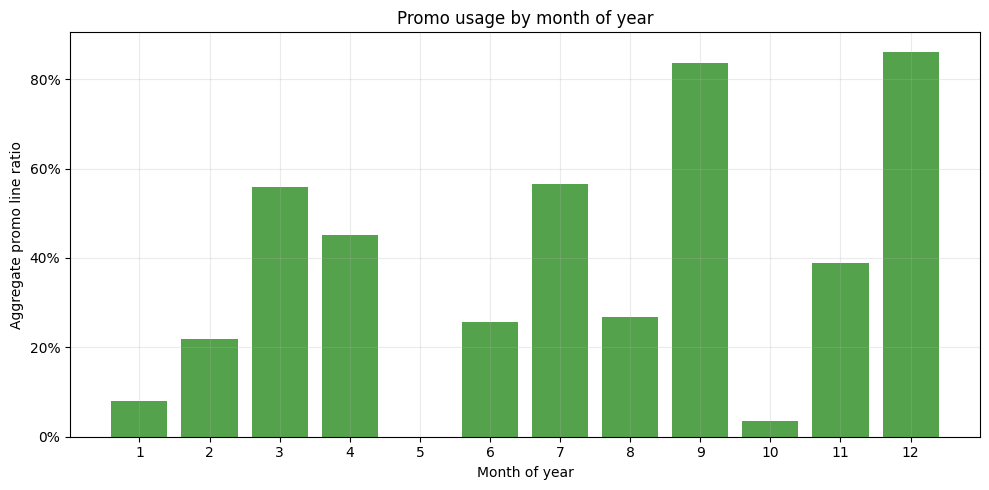

In [11]:
month_of_year_promo = pd.DataFrame()
quarter_promo = pd.DataFrame()

if not daily_promo.empty:
    month_of_year_promo = daily_promo.groupby("month_of_year").agg(
        average_daily_promo_line_ratio=("promo_line_ratio", "mean"),
        median_daily_promo_line_ratio=("promo_line_ratio", "median"),
        total_item_lines=("total_item_lines", "sum"),
        promo_item_lines=("promo_item_lines", "sum"),
        average_unique_promo_count=("unique_promo_count", "mean"),
    ).reset_index()
    month_of_year_promo["aggregate_promo_line_ratio"] = month_of_year_promo["promo_item_lines"] / month_of_year_promo["total_item_lines"].replace(0, np.nan)
    quarter_promo = daily_promo.groupby("quarter").agg(
        average_daily_promo_line_ratio=("promo_line_ratio", "mean"),
        total_item_lines=("total_item_lines", "sum"),
        promo_item_lines=("promo_item_lines", "sum"),
    ).reset_index()
    quarter_promo["aggregate_promo_line_ratio"] = quarter_promo["promo_item_lines"] / quarter_promo["total_item_lines"].replace(0, np.nan)
    display(month_of_year_promo)
    display(quarter_promo)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(month_of_year_promo["month_of_year"].astype(str), month_of_year_promo["aggregate_promo_line_ratio"], color="#54A24B")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("Promo usage by month of year")
    ax.set_xlabel("Month of year")
    ax.set_ylabel("Aggregate promo line ratio")
    plt.tight_layout()
    plt.show()
else:
    display_warning("Promotion intensity seasonality skipped because daily promotion data is unavailable.")

## 12. Leakage-safe promotion forecast feature preview

Candidate promotion-intensity features are historical only. They shift before lagging or rolling, and should not use future promotion usage unless the future promotion calendar is known and allowed.

In [12]:
promo_features = pd.DataFrame()

if not daily_promo.empty:
    promo_features = daily_promo[["date", "total_item_lines", "promo_item_lines", "promo_line_ratio", "unique_promo_count"]].copy()
    if "promo_revenue_share" in daily_promo.columns:
        promo_features["promo_revenue_share"] = daily_promo["promo_revenue_share"]
    shifted_ratio = daily_promo["promo_line_ratio"].shift(1)
    shifted_count = daily_promo["unique_promo_count"].shift(1)
    promo_features["promo_line_ratio_lag_1"] = daily_promo["promo_line_ratio"].shift(1)
    promo_features["promo_line_ratio_lag_7"] = daily_promo["promo_line_ratio"].shift(7)
    promo_features["promo_line_ratio_lag_30"] = daily_promo["promo_line_ratio"].shift(30)
    promo_features["promo_count_lag"] = shifted_count
    promo_features["promo_line_ratio_roll_mean_7"] = shifted_ratio.rolling(7, min_periods=3).mean()
    promo_features["promo_line_ratio_roll_mean_30"] = shifted_ratio.rolling(30, min_periods=7).mean()
    if "promo_revenue_share" in daily_promo.columns:
        promo_features["promo_revenue_share_lag"] = daily_promo["promo_revenue_share"].shift(1)

    temp = promo_features[["date", "promo_line_ratio"]].copy()
    temp["month_of_year"] = temp["date"].dt.month
    temp["historical_promo_intensity_by_month"] = temp.groupby("month_of_year")["promo_line_ratio"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    promo_features["historical_promo_intensity_by_month"] = temp["historical_promo_intensity_by_month"]

    print("Feature preview. Lagged and rolling promotion features are shifted so date t uses only dates before t.")
    display(promo_features.head(40))
else:
    display_warning("Leakage-safe promotion feature preview skipped because daily promotion data is unavailable.")

Feature preview. Lagged and rolling promotion features are shifted so date t uses only dates before t.


,date,total_item_lines,promo_item_lines,promo_line_ratio,unique_promo_count,promo_revenue_share,promo_line_ratio_lag_1,promo_line_ratio_lag_7,promo_line_ratio_lag_30,promo_count_lag,promo_line_ratio_roll_mean_7,promo_line_ratio_roll_mean_30,promo_revenue_share_lag,historical_promo_intensity_by_month
0,2012-07-04,174,0,0.0000,0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,103,0,0.0000,0,0.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,0.0000,0.0000
2,2012-07-06,99,0,0.0000,0,0.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,0.0000,0.0000
3,2012-07-07,75,0,0.0000,0,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000
4,2012-07-08,94,0,0.0000,0,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000
5,2012-07-09,157,0,0.0000,0,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000
6,2012-07-10,203,0,0.0000,0,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN,0.0000,0.0000
7,2012-07-11,243,0,0.0000,0,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000
8,2012-07-12,275,0,0.0000,0,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000
9,2012-07-13,223,0,0.0000,0,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000


## 13. Key observations and warnings

The final summary reports overall promotion line usage, high-intensity periods, promo-heavy categories and segments, revenue context, data-quality warnings, and leakage-safe feature recommendations.

In [13]:
print("Concise insight summary")
print("=" * 80)

if overall_summary:
    print(f"Overall promo line usage rate: {overall_summary['promo_line_usage_rate']:.1%} ({overall_summary['promo_item_lines']:,.0f} of {overall_summary['total_order_item_lines']:,.0f} order-item lines).")
    if "promo_quantity_share" in overall_summary:
        print(f"Share of quantity sold under promotion: {overall_summary['promo_quantity_share']:.1%}.")
    if "promo_revenue_share" in overall_summary:
        print(f"Share of item revenue from promo lines: {overall_summary['promo_revenue_share']:.1%}.")
else:
    print("Overall promo line usage rate: not available.")

if not monthly_promo.empty:
    high_month = monthly_promo.sort_values("promo_line_ratio", ascending=False).iloc[0]
    low_month = monthly_promo.sort_values("promo_line_ratio", ascending=True).iloc[0]
    print(f"Highest promotion-intensity month: {high_month['month'].date()} ({high_month['promo_line_ratio']:.1%}).")
    print(f"Lowest promotion-intensity month: {low_month['month'].date()} ({low_month['promo_line_ratio']:.1%}).")
if not yearly_promo.empty:
    high_year = yearly_promo.sort_values("promo_line_ratio", ascending=False).iloc[0]
    low_year = yearly_promo.sort_values("promo_line_ratio", ascending=True).iloc[0]
    print(f"Highest promotion-intensity year: {int(high_year['year'])} ({high_year['promo_line_ratio']:.1%}).")
    print(f"Lowest promotion-intensity year: {int(low_year['year'])} ({low_year['promo_line_ratio']:.1%}).")

if not category_summary.empty:
    top_categories = category_summary.sort_values("promo_line_ratio", ascending=False).head(5)
    print("Categories with highest promo usage: " + "; ".join(f"{row['category']} ({row['promo_line_ratio']:.1%}, revenue share {row['revenue_share']:.1%})" for row in top_categories.to_dict("records")) + ".")
else:
    print("Categories with highest promo usage: not available.")

if not segment_summary.empty:
    top_segments = segment_summary.sort_values("promo_line_ratio", ascending=False).head(5)
    print("Segments with highest promo usage: " + "; ".join(f"{row['segment']} ({row['promo_line_ratio']:.1%}, revenue share {row['revenue_share']:.1%})" for row in top_segments.to_dict("records")) + ".")
else:
    print("Segments with highest promo usage: not available.")

if not category_quadrants.empty:
    high_rev_high_promo = category_quadrants[category_quadrants["promo_revenue_context"] == "high revenue and high promo usage"].sort_values("revenue_share", ascending=False)
    if not high_rev_high_promo.empty:
        print("Promo-heavy categories that also contribute high revenue: " + "; ".join(f"{row['category']} (promo {row['promo_line_ratio']:.1%}, revenue share {row['revenue_share']:.1%})" for row in high_rev_high_promo.to_dict("records")) + ".")
    else:
        print("Promo-heavy categories that also contribute high revenue: none by the median-threshold rule.")
elif revenue_available:
    print("Promo-heavy category revenue context: not available.")

print("Promotion data quality warnings: " + ("; ".join(quality_warnings) if quality_warnings else "none material for detected fields") + ".")

recommended_features = [
    "promo_line_ratio_lag_1",
    "promo_line_ratio_lag_7",
    "promo_line_ratio_lag_30",
    "promo_count_lag",
    "promo_line_ratio_roll_mean_7",
    "promo_line_ratio_roll_mean_30",
    "historical_promo_intensity_by_month",
]
if revenue_available:
    recommended_features.append("promo_revenue_share_lag")
print("Recommended leakage-safe promotion-intensity forecast features: " + ", ".join(recommended_features) + ".")
print("Forecasting warning: future promotion usage must not be used directly unless the future promotion calendar is known and allowed. The preview features are historical and shifted.")
print("Interpretation warning: promotion usage differences are exploratory associations, not evidence that promotions caused revenue or category behavior.")

Concise insight summary
Overall promo line usage rate: 38.7% (276,316 of 714,669 order-item lines).
Share of quantity sold under promotion: 38.7%.
Share of item revenue from promo lines: 33.1%.
Highest promotion-intensity month: 2021-12-01 (99.8%).
Lowest promotion-intensity month: 2012-07-01 (0.0%).
Highest promotion-intensity year: 2015 (46.5%).
Lowest promotion-intensity year: 2012 (0.0%).
Categories with highest promo usage: Outdoor (41.7%, revenue share 15.2%); Streetwear (37.5%, revenue share 79.9%); Casual (33.7%, revenue share 2.8%); GenZ (32.9%, revenue share 2.1%).
Segments with highest promo usage: Activewear (42.0%, revenue share 12.5%); Standard (39.2%, revenue share 1.4%); Premium (39.1%, revenue share 2.9%); Balanced (38.1%, revenue share 31.2%); Performance (37.5%, revenue share 14.5%).
Promo-heavy categories that also contribute high revenue: Streetwear (promo 37.5%, revenue share 79.9%); Outdoor (promo 41.7%, revenue share 15.2%).
Promotion data quality warnings: none